TEST MODE: Processing 1282 images.


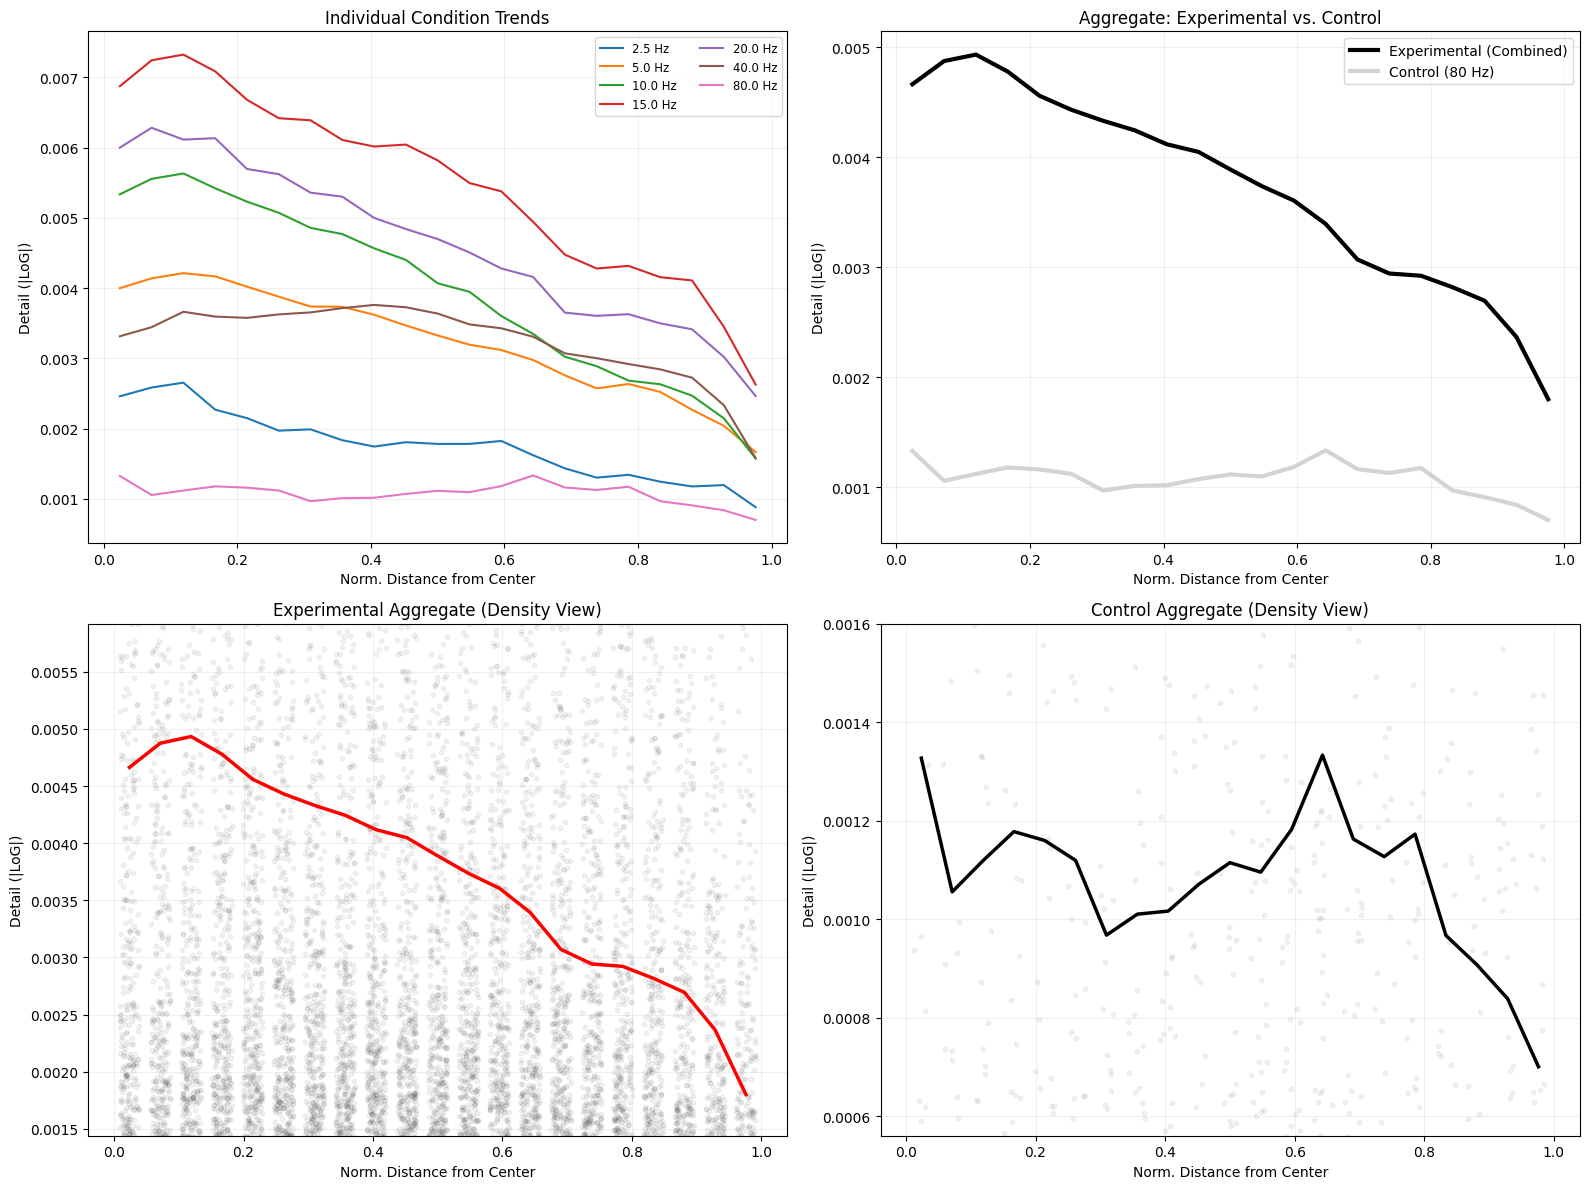

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, gaussian_laplace
from pathlib import Path

# ==========================================
# 1. PARAMETERS & CONFIGURATION
# ==========================================
TEST_MODE = True           # Toggle to False for the full 1300+ image run
TEST_SAMPLE_SIZE = 1000000      # Sample size for validation
N_BINS = 21                # Number of radial bins
DETAIL_LOG_SIGMA = 1.0     
CROP_PIXELS = 12           

# Conditions
EXP_HZ = [2.5, 5.0, 10.0, 15.0, 20.0, 40.0]
CONTROL_HZ = [80.0]
ALL_CONDITIONS = EXP_HZ + CONTROL_HZ

# Paths
CUR_DIR = Path().resolve()
PROJECT_ROOT = CUR_DIR.parent 
TABLES_PATH = PROJECT_ROOT / "015_tables"
IMAGES_PATH = PROJECT_ROOT / "005_cleaned_data"
VIZ_PATH = PROJECT_ROOT / "020_visualizations"

# ==========================================
# 2. STANDALONE LOGIC
# ==========================================

def preprocess_image(path):
    with Image.open(path) as img:
        arr = np.asarray(img.convert("L"), dtype=np.float32) / 255.0
    h, w = arr.shape
    arr = arr[CROP_PIXELS : h - CROP_PIXELS, CROP_PIXELS : w - CROP_PIXELS]
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    arr = (arr - mn) / (mx - mn + 1e-8)
    return gaussian_filter(arr, sigma=1.0)

def get_radial_detail(preprocessed_img, n_bins=N_BINS):
    detail_map = np.abs(gaussian_laplace(preprocessed_img, sigma=DETAIL_LOG_SIGMA))
    h, w = detail_map.shape
    yy, xx = np.indices((h, w))
    center_y, center_x = (h - 1) / 2.0, (w - 1) / 2.0
    dist = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    dist_norm = dist / np.sqrt(center_x**2 + center_y**2)
    
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_values = [np.mean(detail_map[(dist_norm >= bins[i]) & (dist_norm < bins[i+1])]) for i in range(n_bins)]
    return bin_centers, np.array(bin_values)

# ==========================================
# 3. EXECUTION
# ==========================================

def main():
    csv_path = TABLES_PATH / "vizex_trials.csv"
    if not csv_path.exists(): return print(f"File not found: {csv_path}")

    df = pd.read_csv(csv_path)
    # CORRECTED FILTER: Explicitly target the '_cropped.png' suffix
    df = df[df['png_filename'].astype(str).str.endswith('_cropped.png')].copy()
    df = df[df['condition_hz'].isin(ALL_CONDITIONS)]

    if TEST_MODE:
        df = df.sample(min(TEST_SAMPLE_SIZE, len(df)), random_state=42)
        print(f"TEST MODE: Processing {len(df)} images.")
    else:
        print(f"Processing {len(df)} images.")

    data = []
    for _, row in df.iterrows():
        img_file = IMAGES_PATH / row['png_filename']
        if not img_file.exists(): continue
        try:
            centers, values = get_radial_detail(preprocess_image(img_file))
            for c, v in zip(centers, values):
                data.append({'hz': row['condition_hz'], 'dist': c, 'detail': v, 
                             'type': 'Experimental' if row['condition_hz'] != 80 else 'Control'})
        except Exception: continue

    res_df = pd.DataFrame(data)
    if res_df.empty: return print("No data processed.")

    # --- PLOTTING (4 Panels) ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    jitter = lambda x: x + np.random.uniform(-0.015, 0.015, len(x))

    # Plot 1: All Conditions (Lines Only)
    ax = axes[0, 0]
    for hz in sorted(ALL_CONDITIONS):
        subset = res_df[res_df['hz'] == hz].groupby('dist')['detail'].mean()
        ax.plot(subset.index, subset.values, label=f"{hz} Hz", linewidth=1.5)
    ax.set_title("Individual Condition Trends")
    ax.legend(ncol=2, fontsize='small')

    # Plot 2: Aggregate Experimental vs Control (Lines Only)
    ax = axes[0, 1]
    exp_mean = res_df[res_df['type'] == 'Experimental'].groupby('dist')['detail'].mean()
    ctrl_mean = res_df[res_df['type'] == 'Control'].groupby('dist')['detail'].mean()
    ax.plot(exp_mean.index, exp_mean.values, color='black', linewidth=3, label='Experimental (Combined)')
    ax.plot(ctrl_mean.index, ctrl_mean.values, color='lightgrey', linewidth=3, label='Control (80 Hz)')
    ax.set_title("Aggregate: Experimental vs. Control")
    ax.legend()

    # Plot 3: Experimental Combined + Points
    ax = axes[1, 0]
    exp_data = res_df[res_df['type'] == 'Experimental']
    ax.scatter(jitter(exp_data['dist']), exp_data['detail'], color='black', alpha=0.05, s=10)
    ax.plot(exp_mean.index, exp_mean.values, color='red', linewidth=2.5) # Red for visibility against black points
    ax.set_ylim(exp_mean.min() * 0.8, exp_mean.max() * 1.2) # Crop to line scale
    ax.set_title("Experimental Aggregate (Density View)")

    # Plot 4: Control Only + Points
    ax = axes[1, 1]
    ctrl_data = res_df[res_df['type'] == 'Control']
    ax.scatter(jitter(ctrl_data['dist']), ctrl_data['detail'], color='grey', alpha=0.1, s=10)
    ax.plot(ctrl_mean.index, ctrl_mean.values, color='black', linewidth=2.5)
    ax.set_ylim(ctrl_mean.min() * 0.8, ctrl_mean.max() * 1.2) # Crop to line scale
    ax.set_title("Control Aggregate (Density View)")

    for a in axes.flat:
        a.set_xlabel("Norm. Distance from Center")
        a.set_ylabel("Detail (|LoG|)")
        a.grid(True, alpha=0.2)

    plt.tight_layout()
    os.makedirs(VIZ_PATH, exist_ok=True)
    plt.savefig(VIZ_PATH / "radial_detail_multiplot.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    main()

--- Seed: 194231 (use this to recreate this exact layout) ---
Building square-locked 4x2 blocks...


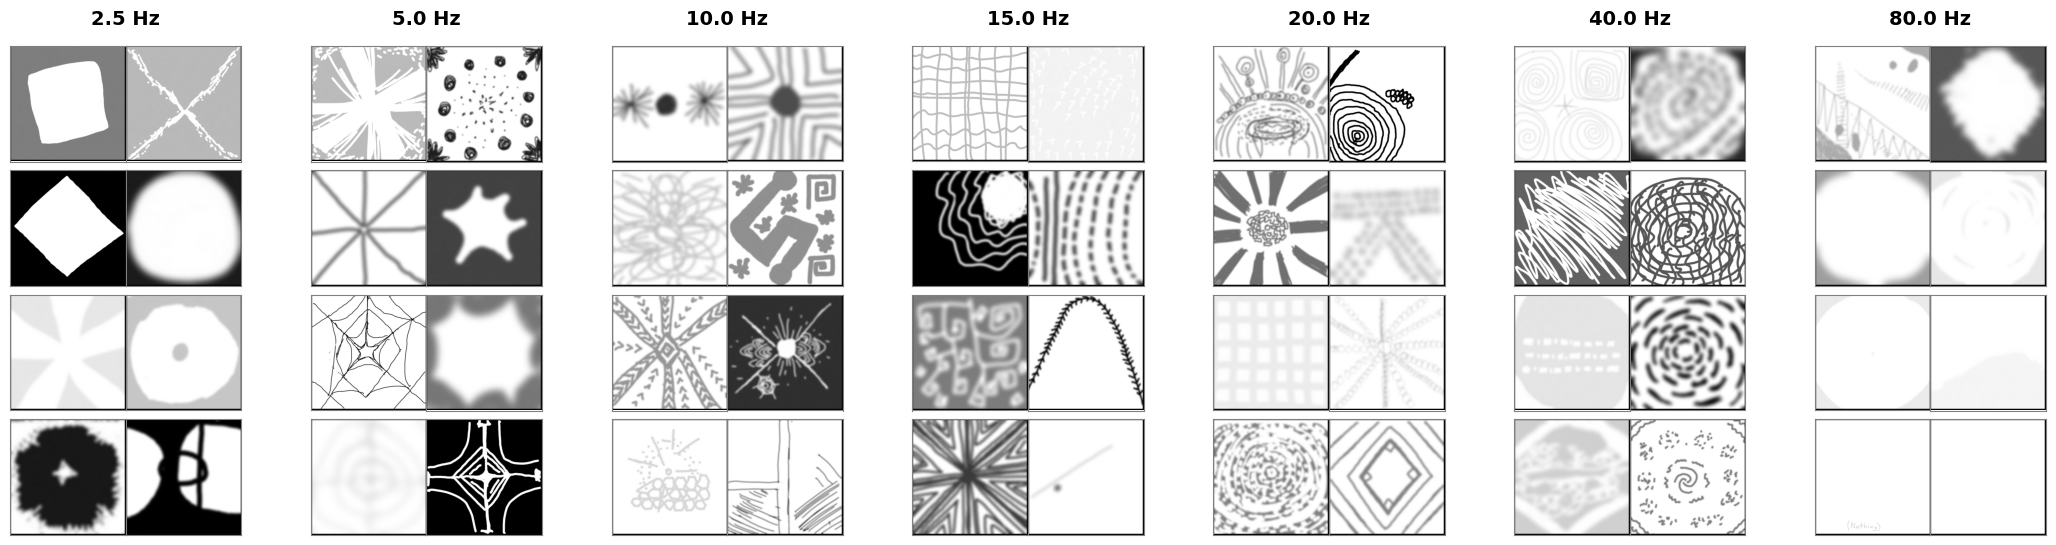

Grid saved to: E:\Research2\VizEx_analysis_replication\020_visualizations\square_glued_grid.png


In [16]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# ==========================================
# 1. CONFIGURATION & SEEDING
# ==========================================
# Set a specific integer for reproducibility or None for random
RANDOM_SEED = None 

# Grid dimensions PER condition
ROWS_PER_COND = 4
COLS_PER_COND = 2
SAMPLES_PER_COND = ROWS_PER_COND * COLS_PER_COND

# Conditions in display order
TARGET_HZ = [2.5, 5.0, 10.0, 15.0, 20.0, 40.0, 80.0]

# Paths
PROJECT_ROOT = Path('.').resolve().parent
TABLES_PATH = PROJECT_ROOT / "015_tables"
IMAGES_PATH = PROJECT_ROOT / "005_cleaned_data"
VIZ_PATH = PROJECT_ROOT / "020_visualizations"

# ==========================================
# 2. SEED INITIALIZATION
# ==========================================
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    seed_val = RANDOM_SEED
else:
    seed_val = random.randint(0, 999999)
    random.seed(seed_val)
    np.random.seed(seed_val)

print(f"--- Seed: {seed_val} (use this to recreate this exact layout) ---")

# ==========================================
# 3. EXECUTION
# ==========================================
def main():
    csv_path = TABLES_PATH / "vizex_trials.csv"
    if not csv_path.exists():
        return print(f"Error: {csv_path} not found.")

    df = pd.read_csv(csv_path)

    # STRICT FILTER: Captures only the final '_cropped.png' files.
    # This prevents counting the '_uncropped.png' setup images.
    df = df[df['png_filename'].astype(str).str.endswith('_cropped.png')].copy()
    df = df[df['condition_hz'].isin(TARGET_HZ)]

    n_cond = len(TARGET_HZ)
    
    # --- PROPORTIONAL LAYOUT ---
    # To keep 1:1 images square without stretching, the figure dimensions
    # must reflect the total number of columns vs rows.
    unit_size = 1.5 
    fig_width = n_cond * COLS_PER_COND * unit_size * 1.01 # 1.1 multiplier accounts for inter-condition gaps
    fig_height = ROWS_PER_COND * unit_size
    
    fig = plt.figure(figsize=(fig_width, fig_height))
    
    # Outer Grid: 1 row, N condition columns. wspace creates the gap BETWEEN conditions.
    outer_gs = fig.add_gridspec(1, n_cond, wspace=0.3)

    print(f"Building square-locked {ROWS_PER_COND}x{COLS_PER_COND} blocks...")

    for cond_idx, hz in enumerate(TARGET_HZ):
        subset = df[df['condition_hz'] == hz]
        
        if len(subset) < SAMPLES_PER_COND:
            samples = subset
        else:
            samples = subset.sample(n=SAMPLES_PER_COND, replace=False)
            
        # Inner Grid: wspace/hspace=0 removes gaps WITHIN a condition.
        inner_gs = outer_gs[cond_idx].subgridspec(ROWS_PER_COND, COLS_PER_COND, wspace=0, hspace=0)
        
        for i, (_, row) in enumerate(samples.iterrows()):
            r = i // COLS_PER_COND
            c = i % COLS_PER_COND
            
            ax = fig.add_subplot(inner_gs[r, c])
            img_path = IMAGES_PATH / row['png_filename']
            
            try:
                with Image.open(img_path) as img:
                    # aspect='equal' ensures squares remain squares.
                    # aspect='auto' (removed) was the cause of stretching.
                    ax.imshow(img.convert("L"), cmap='gray', aspect='equal')
            except Exception:
                ax.text(0.5, 0.5, "Err", ha='center', va='center', color='red')
            
            # Formatting
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor('0.5') # 50% Grey border
                spine.set_linewidth(0.8)
                spine.set_visible(True)

            # Header: Centered over the 2-column block
            if r == 0 and c == 0:
                # 1.0 on the x-axis of the first column is the exact midpoint of the 2-col block
                ax.text(1.0, 1.15, f"{hz} Hz", transform=ax.transAxes,
                        fontweight='bold', fontsize=14, va='bottom', ha='center')

    # Maintain top margin for bold condition titles
    plt.subplots_adjust(top=0.88, bottom=0.05, left=0.02, right=0.98)
    
    os.makedirs(VIZ_PATH, exist_ok=True)
    save_path = VIZ_PATH / "square_glued_grid.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Grid saved to: {save_path}")

if __name__ == "__main__":
    main()